In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

gapminder = px.data.gapminder()     # life expectancy, GDP, population by country & year
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## EDA Task

**Exercise 1.** With `px.scatter` on the 2007 gapminder data, plot population (`log_x=True`) vs life expectancy, colored by continent. Hover around: which *country* is the small-population outlier with very low life expectancy?

**Exercise 2.** Build an interactive box plot of `lifeExp` per continent for **1952** and another for **2007**. Which continent improved the most?

**Exercise 3.** Pick any 3 countries and draw their `gdpPercap` over time with `px.line`. Write three observations (claim + number each).

**Exercise 4 (mini-report).** Run the full Part-B pipeline on the `tips` dataset: one question, inspect, (light) clean, engineer one feature (e.g. tip percentage), two plots, one conclusion. This is a dress rehearsal for report!

In [3]:
# Exercise 1
g2007 = gapminder[gapminder["year"] == 2007]

fig = px.scatter(
    g2007,
    x="pop",
    y="lifeExp",
    color="continent",
    log_x=True,
    hover_name="country",
    title="Population vs. Life Expectancy (2007)"
)
fig.show()

In [4]:
# Exercise 2

g_two_years = gapminder[gapminder["year"].isin([1952, 2007])]

g_two_years["year_str"] = g_two_years["year"].astype(str)

fig = px.box(
    g_two_years,
    x="continent",
    y="lifeExp",
    color="year_str",
    title="Life Expectancy by Continent (1952 vs 2007)"
)
fig.show()

In [5]:
# Exercise 3
my_countries = gapminder[gapminder["country"].isin(["China", "India", "United States"])]

fig = px.line(
    my_countries,
    x="year",
    y="gdpPercap",
    color="country",
    markers=True,
    title="GDP Per Capita Over Time (China, India, US)"
)
fig.show()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


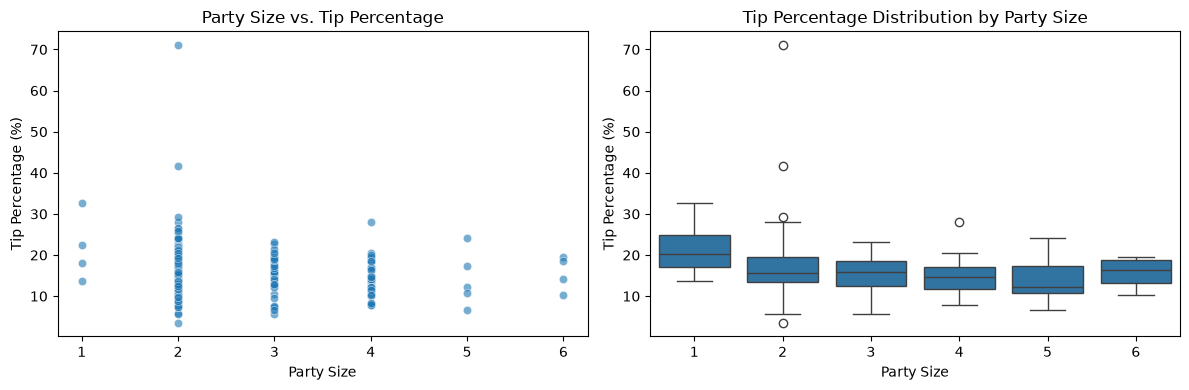

In [6]:
# Exercise 4 — mini report
tips = sns.load_dataset("tips")
print(tips.info())
tips["tip_pct"] = (tips["tip"] / tips["total_bill"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=tips, x="size", y="tip_pct", alpha=0.6, ax=axes[0])
axes[0].set_title("Party Size vs. Tip Percentage")
axes[0].set_xlabel("Party Size")
axes[0].set_ylabel("Tip Percentage (%)")

sns.boxplot(data=tips, x="size", y="tip_pct", ax=axes[1])
axes[1].set_title("Tip Percentage Distribution by Party Size")
axes[1].set_xlabel("Party Size")
axes[1].set_ylabel("Tip Percentage (%)")

fig.tight_layout()
plt.show()